# **_USML ACTIVE LEARNING STATISTICAL ANALYSIS_**

---

In [2]:
# imports
import itertools
import json
import warnings
from random import choice
from typing import Any

import numpy as np
import pandas as pd
import pingouin as pg
import plotly.express as px
import seaborn as sns
from matplotlib import pyplot as plt

from DirectedGraph import DirectedGraph

In [ ]:
global metric_options
metric_options = ['information_gain', 'minority_partition']

modifications = [
    'exclude_t>60',
    'exclude_missing',
    'rescale_top',  # re-scales top-end metrics, keeps 0 at 0
    'save',
    # 'simulate',
]

global plotmode
plotmode = 'seaborn'
# plotmode = 'plotly'

sns.set_theme(style = 'whitegrid', rc={'figure.figsize':(8, 5), 'figure.dpi':300, 'pgf.texsystem' : 'pdflatex', 'pgf.preamble' : r'\usepackage[utf8]{inputenc}\usepackage[T1]{fontenc}', 'axes.labelsize' : '20', 'font.size' : '20', 'xtick.labelsize' : '16', 'figure.autolayout' : True})

## **_Loading Data_**

In [4]:
df = pd.read_csv('./resources/data_usml-meta-learning_2025-07-17_20-06.csv')

In [5]:
# remove unnecessary columns
df = df.drop([
    'CASE',
    'SERIAL',
    'REF',
    'QUESTNNR',
    'MODE',
    'STARTED',
    'RD01_CP',
    'RD01',
    'RD02_CP',
    'RD02',
    'SD11_10',
    'MAILSENT',
    'LASTDATA',
    'STATUS',
    'FINISHED',
    'Q_VIEWER',
    'LASTPAGE',
    'MAXPAGE',
    'MISSING',
    'MISSREL',
    'DI08',
    'DI13',
    'DI14',
    'LP02',
    'SC01',
    'SD19_01',
    'TIME018',
    'TIME016',
    'TIME010',
    'TIME006',
    'TIME003',
    'TIME001'
], axis = 1)

## **_Preparing Data_**

**_Condition Variables to Categorical_**

In [6]:
df['IV01_01'] = pd.Categorical(df['IV01_01'].astype(int))   # 1 is explanation
df['IV02_01'] = pd.Categorical(df['IV02_01'].astype(int))   # 1 is water first

df = df.rename({'IV01_01' : 'condition', 'IV02_01' : 'domain_order'}, axis = 1)

**_Learning Phase Categoricals_**

In [7]:
# LP02
for col in [f'LP02_0{i}' for i in range(1, 10)]:
    df[col] = (df[col] - 1).astype(bool)

# LP03
for col in [f'LP03_0{i}' for i in range(1, 6)]:
    df[col] = pd.Categorical(df[col].astype(int))
    if -9 in df[col].dtype.categories: # type: ignore
        print(f'[ERROR]: {col} contains invalid values.')

# LP04
for col in [f'LP04_0{i}' for i in range(1, 5)]:
    df[col] = pd.Categorical(df[col].astype(int))
    if -9 in df[col].dtype.categories: # type: ignore
        print(f'[ERROR]: {col} contains invalid values.')

**_Sociodemographics_**

In [8]:
# gender
df['SD01'] = pd.Categorical(df['SD01'].replace([1.0, 2.0, 3.0], ['female', 'male', 'other']))

# age
df['SD02_01'] = df['SD02_01'].astype(int)

# education
df['SD11'] = pd.Categorical(
    df['SD11'].replace(
        [1.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0],
        [
            'Finished school with no qualifications',
            'Secondary school-leaving certificate/Junior High Diploma',
            'High school diploma/Intermediate/General Certificate of Secondary Education, secondary school-leaving certificate or equivalent',
            'Completed apprenticeship',
            'Vocational baccalaureate diploma, vocational secondary certification',
            'A-levels/International Baccalaureate/Higher education entrance qualification',
            'Vocational university/university of applied sciences/university degree',
            'Still in school',
            'Other degree:'
        ]
    )
)

# replace other degree: 3rd year University Student with the appropriate A-levels/... (there is only this one occurence)
with warnings.catch_warnings():
    warnings.simplefilter(action = 'ignore', category = FutureWarning)  # we can ignore this because the intended behavior is maintained in the future version.
    df['SD11'] = df['SD11'].replace('Other degree:', 'A-levels/International Baccalaureate/Higher education entrance qualification')

**_Gender._**

In [9]:
df.groupby('SD01', observed = True).count()

,condition,domain_order,LP02_01,LP02_02,LP02_03,LP02_04,LP02_05,LP02_06,LP02_07,LP02_08,...,TIME030,TIME031,TIME032,TIME033,TIME034,TIME035,TIME036,TIME037,TIME_SUM,TIME_RSI
SD01,,,,,,,,,,,,,,,,,,,,,
female,49,49,49,49,49,49,49,49,49,49,...,49,49,49,49,49,49,49,49,49,49
male,50,50,50,50,50,50,50,50,50,50,...,50,50,50,50,50,50,50,50,50,50
other,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


**_Age._**

In [10]:
print(df['SD02_01'].mean())
print(df['SD02_01'].std())

34.58
12.247597166939984


**_Sanity Checks_**

In [51]:
# first sanity check should be 3.0
df['SN01'] = df['SN01'] == 3.0

# second sanity check should be 2.0
df['SN02'] = df['SN02'] == 2.0

# third sanity check should be 2.0
df['SN03'] = df['SN03'] == 2.0

**_Trials_**

In [52]:
# make all trials categorical
for col in [f'TR{i:02d}' for i in range(23)]:
    if col not in df.columns:
        continue
    else:
        df[col] = pd.Categorical(df[col].astype(int))
        if -9 in df[col].dtype.categories: # type: ignore
            print(f'[ERROR]: {col} contains invalid values.')

# re-name trials to match order in questionnaire
df = df.rename({
    'TR01' : 'crct01',      # = ex01
    'TR04' : 'crct02',      # = ex03
    'TR12' : 'crct03',      # = ex11
    'TR13' : 'crct04',      # = ex12
    'TR07' : 'crct05',      # = ex06
    'TR03' : 'flow01',      # = ex02
    'TR06' : 'flow02',      # = ex05
    'TR09' : 'flow03',      # = ex08
    'TR10' : 'flow04',      # = ex09
    'TR11' : 'flow05',      # = ex10
    'TR18' : 'list01',
    'TR19' : 'list02',
    'TR20' : 'list03',
    'TR21' : 'list04',
    'TR22' : 'list05'
}, axis = 1)

trial_cols = [f'{tr}0{n}' for tr, n in itertools.product(['crct', 'flow', 'list'], range(1, 6))]

**_Page Timing_**

In [53]:
# renaming time columns for easier association
df = df.rename({
    'TIME004' : 't_init_intro_1',
    'TIME005' : 't_init_intro_2',
    'TIME007' : 't_LP02_task',
    'TIME008' : 't_LP02_expl',
    'TIME009' : 't_SN01',
    'TIME011' : 't_LP03_task',
    'TIME012' : 't_LP03_expl',
    'TIME013' : 't_LP04_task',
    'TIME014' : 't_LP04_expl',
    'TIME015' : 't_SN02',
    'TIME017' : 't_SN03',
    'TIME019' : 't_break',
    'TIME020' : 't_intro_crct',
    'TIME026' : 't_intro_flow',
    'TIME032' : 't_intro_list',
    'TIME_SUM' : 't_total',
    'TIME_RSI' : 't_rel'
}, axis = 1)

df = df.rename({f'TIME{k:03d}' : f't_crct{v:02d}' for k, v in zip(range(21, 26), range(1, 6))}, axis = 1)
df = df.rename({f'TIME{k:03d}' : f't_flow{v:02d}' for k, v in zip(range(27, 32), range(1, 6))}, axis = 1)
df = df.rename({f'TIME{k:03d}' : f't_list{v:02d}' for k, v in zip(range(33, 38), range(1, 6))}, axis = 1)

## **_Introducing Performance Metrics_**

In [55]:
for trial_name in trial_cols:
    with open(f'./resources/{trial_name}.json', 'r') as f:
        strct = json.load(f)

    tr_df : pd.DataFrame = pd.DataFrame()

    grph = DirectedGraph(strct)
    for node in grph.get_inner():
        metrics = [
            grph.information_gain(node),
            grph.minority_partition(node)
        ]
        tr_df[node.name] = metrics

    # add distractor elements for lists
    if trial_name == 'list01':
        tr_df['4'] = [0.0] * 2
        tr_df['5'] = [0.0] * 2
    if trial_name == 'list04':
        tr_df['1'] = [0.0] * 2
        tr_df['5'] = [0.0] * 2
        tr_df['6'] = [0.0] * 2

    tr_df.to_csv(f'./resources/{trial_name}.csv', index = False)

In [56]:
df_ig = df.copy()
df_mp = df.copy()

for trial_col in trial_cols:
    ref_df = pd.read_csv(f'./resources/{trial_col}.csv')
    
    if 'rescale_top' in modifications:
        ref_df = ref_df.agg(lambda x: x / max(x), axis = 1)

    df_ig[trial_col] = df_ig[trial_col].astype(str).replace(ref_df.iloc[0]).astype(float)
    df_mp[trial_col] = df_mp[trial_col].astype(str).replace(ref_df.iloc[1]).astype(float)



In [57]:
# choose metric to use:
metric_choice = int(input('0 : information_gain, 1 : minority_partition'))

match metric_options[metric_choice]:
    case 'information_gain':
        df = df_ig
    case 'minority_partition':
        df = df_mp
    case _:
        raise ValueError

## **_Analyse Time Spent_**
**_Compare time spent on pages._**

In [58]:
# calculate per-participant mean trial time and add to df
t_trial_cols = [f't_{col}' for col in trial_cols]
mean_trial_time_by_participant = df.filter(t_trial_cols, axis = 1).agg('mean', axis = 1).values
df['t_mean_trial'] = mean_trial_time_by_participant

if 'exclude_t>60' in modifications:
    print(f'Mean time spent before: {df['t_mean_trial'].mean()}, sd {df['t_mean_trial'].std()}')
    df = df[df['t_mean_trial'] < 60]
    print(f'Remaining participants: {len(df)}')
    print(f'Out of those condition 1: {len(df[df['condition'] == 1])}\n')

# t_test
t_trial_time = pg.ttest(
    x = df[df['condition'] == 1]['t_mean_trial'],
    y = df[df['condition'] == 2]['t_mean_trial'],
    alternative = 'greater'
)
pg.print_table(t_trial_time)

fig_trial_time = px.bar(
    (_df := df.groupby('condition', observed = True)['t_mean_trial'].agg(['mean', 'sem'])),
    x = _df.index,
    y = 'mean',
    error_y = 'sem',
    color = _df.index,
    width = 800,
    title = '<b>Mean Time Spent on Trials (SEM Error Bars)</b>'
)
fig_trial_time.show()

Mean time spent before: 38.19866666666667, sd 24.72421529589474
Remaining participants: 83
Out of those condition 1: 58

    T     dof  alternative      p-val  CI95%            cohen-d    BF10    power
-----  ------  -------------  -------  -------------  ---------  ------  -------
0.841  48.359  greater          0.202  [-2.36   inf]      0.196   0.666    0.203



In [59]:
fig_t_scatter = px.scatter(
    df,
    x = 't_mean_trial',
    y = 'condition',
    color = 'condition',
    marginal_x = 'histogram',
    title = '<b>Distribution of Mean Time Spent on Trials</b>',
    width = 800
)
fig_t_scatter.show()

**_TL/DR: While there is a significant difference in time spent on trials, there are no outliers in group 1 towards the left which would justify exclusion._**

## **_Check Domain Order Effect_**

In [63]:
df_anova = df.reset_index().melt(id_vars = ['condition', 'index', 'domain_order'], value_vars = trial_cols, var_name = 'trial', value_name = 'metric')

if 'exclude_missing' in modifications:
    df_anova = df_anova[df_anova['metric'] != -1]

In [64]:
anova = pg.kruskal(
    data = df_anova,
    dv = 'metric',
    between = 'domain_order'
)
pg.print_table(anova)

Source          ddof1      H    p-unc
------------  -------  -----  -------
domain_order        1  1.630    0.202



## **_Check Education Effect_**

**_Visualize_**

In [66]:
with warnings.catch_warnings():
    warnings.simplefilter(action = 'ignore', category = FutureWarning)
    _df = df.replace(
        [
            'Finished school with no qualifications',
            'High school diploma/Intermediate/General Certificate of Secondary Education, secondary school-leaving certificate or equivalent',
            'Completed apprenticeship',
            'A-levels/International Baccalaureate/Higher education entrance qualification',
            'Vocational university/university of applied sciences/university degree',
            'Vocational baccalaureate diploma, vocational secondary certification',
        ],
        [
            'No Qual.',
            'High School',
            'Apprenticeship',
            'A-levels',
            'College Degree',
            'Vocational Qual.'
        ]
    )

n_edu = _df.reset_index(names = 'id').groupby('SD11', observed = True)['id'].count()
_df['n_edu'] = [n_edu[row['SD11']] for _, row in _df.iterrows()]

_df = _df.reset_index().melt(
    id_vars = ['index', 'SD11', 'n_edu'],
    value_vars = trial_cols,
    var_name = 'trial',
    value_name = 'metric').groupby(
        'SD11',
        observed = True)[['metric', 'n_edu']].agg(['mean', 'sem'])

_df.columns = ['mean', 'sem', 'n', 'cut']
_df = _df.drop('cut', axis = 1)

fig_edu = px.bar(
    _df,
    x = _df.index,
    y = 'mean',
    error_y = 'sem',
    color = 'n',
    # text = [f'{"<br>"*2}{n}' for n in _df['n']],
    # text = 'n',
    width = 800,
    range_y = [-0.1,1.1],
    title = '<b>Mean Scores per Education Level</b>'
)

fig_edu.add_annotation(
    x = 'A-levels',
    text = '16',
    showarrow = False,
    font = {'color' : 'white'}
)
fig_edu.add_annotation(
    x = 'Apprenticeship',
    text = '4',
    showarrow = False,
    font = {'color' : 'white'}
)
fig_edu.add_annotation(
    x = 'No Qual.',
    text = '2',
    showarrow = False,
    font = {'color' : 'white'}
)
fig_edu.add_annotation(
    x = 'High School',
    text = '53',
    showarrow = False,
)
fig_edu.add_annotation(
    x = 'Vocational Qual.',
    text = '3',
    showarrow = False,
    font = {'color' : 'white'}
)
fig_edu.add_annotation(
    x = 'College Degree',
    text = '5',
    showarrow = False,
    font = {'color' : 'white'}
)

fig_edu.show()

In [67]:
with warnings.catch_warnings():
    warnings.simplefilter(action = 'ignore', category = FutureWarning)
    _df = df.replace(
        [
            'Finished school with no qualifications',
            'High school diploma/Intermediate/General Certificate of Secondary Education, secondary school-leaving certificate or equivalent',
            'Completed apprenticeship',
            'A-levels/International Baccalaureate/Higher education entrance qualification',
            'Vocational university/university of applied sciences/university degree',
            'Vocational baccalaureate diploma, vocational secondary certification',
        ],
        [
            'No Qual.',
            'High School',
            'Apprenticeship',
            'A-levels',
            'College Degree',
            'Vocational Qual.'
        ]
    )

_df = _df.reset_index().melt(
    id_vars = ['index', 'SD11', 'condition'],
    value_vars = trial_cols,
    var_name = 'trial',
    value_name = 'metric')

_df['SD11'] = _df['SD11'].cat.remove_unused_categories()
_df['SD11'].cat.categories

pg.print_table(
    pg.kruskal(
        _df,
        dv = 'metric',
        between = 'SD11'
    )
)

Source      ddof1      H    p-unc
--------  -------  -----  -------
SD11            5  7.742    0.171



## **_Simulate Responses_**

In [68]:
if 'simulate' in modifications:
    n = 50
    random_df = pd.DataFrame()
    for col in trial_cols:
        ref_df = pd.read_csv(f'./resources/{col}.csv')
        row = 1 if metric_options[metric_choice] == 'minority_partition' else 0
        random_resp = [choice(ref_df.loc[row].values) for _ in range(n)]
        random_df = pd.concat([random_df, pd.DataFrame({col : random_resp})], axis = 1)

    random_df['condition'] = 3
    random_df.index = pd.Index([i for i in range(100, 100 + n)])
    df = pd.concat([df, random_df])
    df['condition'] = pd.Categorical(df['condition'])

## **_Hypothesis 1_**
**_Humans who saw explanations perform better than humans who did not on the training task (circuits)._**

In [69]:
crct_trials = [col for col in trial_cols if 'crct' in col]
df_h1 = df.reset_index().melt(id_vars = ['condition', 'index', 'SD11'], value_vars = crct_trials, var_name = 'trial', value_name = 'metric')
df_h1['condition'] = df_h1['condition'].cat.rename_categories(['exp', 'cntrl']) if 'simulate' not in modifications else df_h1['condition'].cat.rename_categories(['exp', 'cntrl', 'rnd'])

if 'exclude_missing' in modifications:
    df_h1 = df_h1[df_h1['metric'] != -1]

In [70]:
if plotmode == 'plotly':
    fig_h1 = px.bar(
        (_df := df_h1.groupby(['condition', 'trial'], observed = True)['metric'].agg(['mean', 'sem'])),
        x = _df.index.get_level_values(1),
        y = 'mean',
        error_y = 'sem',
        color = _df.index.get_level_values(0),
        width = 800,
        title = '<b>Circuit Domain</b>',
        barmode = 'group'
    )
elif plotmode == 'seaborn':
    plt.figure()
    with warnings.catch_warnings():
        warnings.filterwarnings(action = 'ignore', category = UserWarning)
        fig_h1 = sns.barplot(
            data = df_h1,
            x = 'trial',
            y = 'metric',
            hue = 'condition',
            errorbar = 'se',
            palette = sns.color_palette('Set2')
        )
    plt.legend(title = 'condition', fontsize = 'large', title_fontsize = 'large')
    plt.savefig('./plots/fig_q3.pgf') if 'save' in modifications else None


t_h1 = pg.mwu(
    x = df_h1[df_h1['condition'] == 'exp']['metric'],
    y = df_h1[df_h1['condition'] == 'cntrl']['metric'],
    alternative = 'greater'
)
norm = pg.normality(df_h1, 'metric', group = 'condition')
var = pg.homoscedasticity(df_h1, 'metric', group = 'condition')
pg.print_table(norm)
pg.print_table(var)

plt.close()

    W    pval  normal
-----  ------  --------
0.709   0.000  False
0.693   0.000  False

    W    pval  equal_var
-----  ------  -----------
0.939   0.333  True



    U-val  alternative      p-val    RBC    CLES
---------  -------------  -------  -----  ------
18514.500  greater          0.130  0.067   0.533



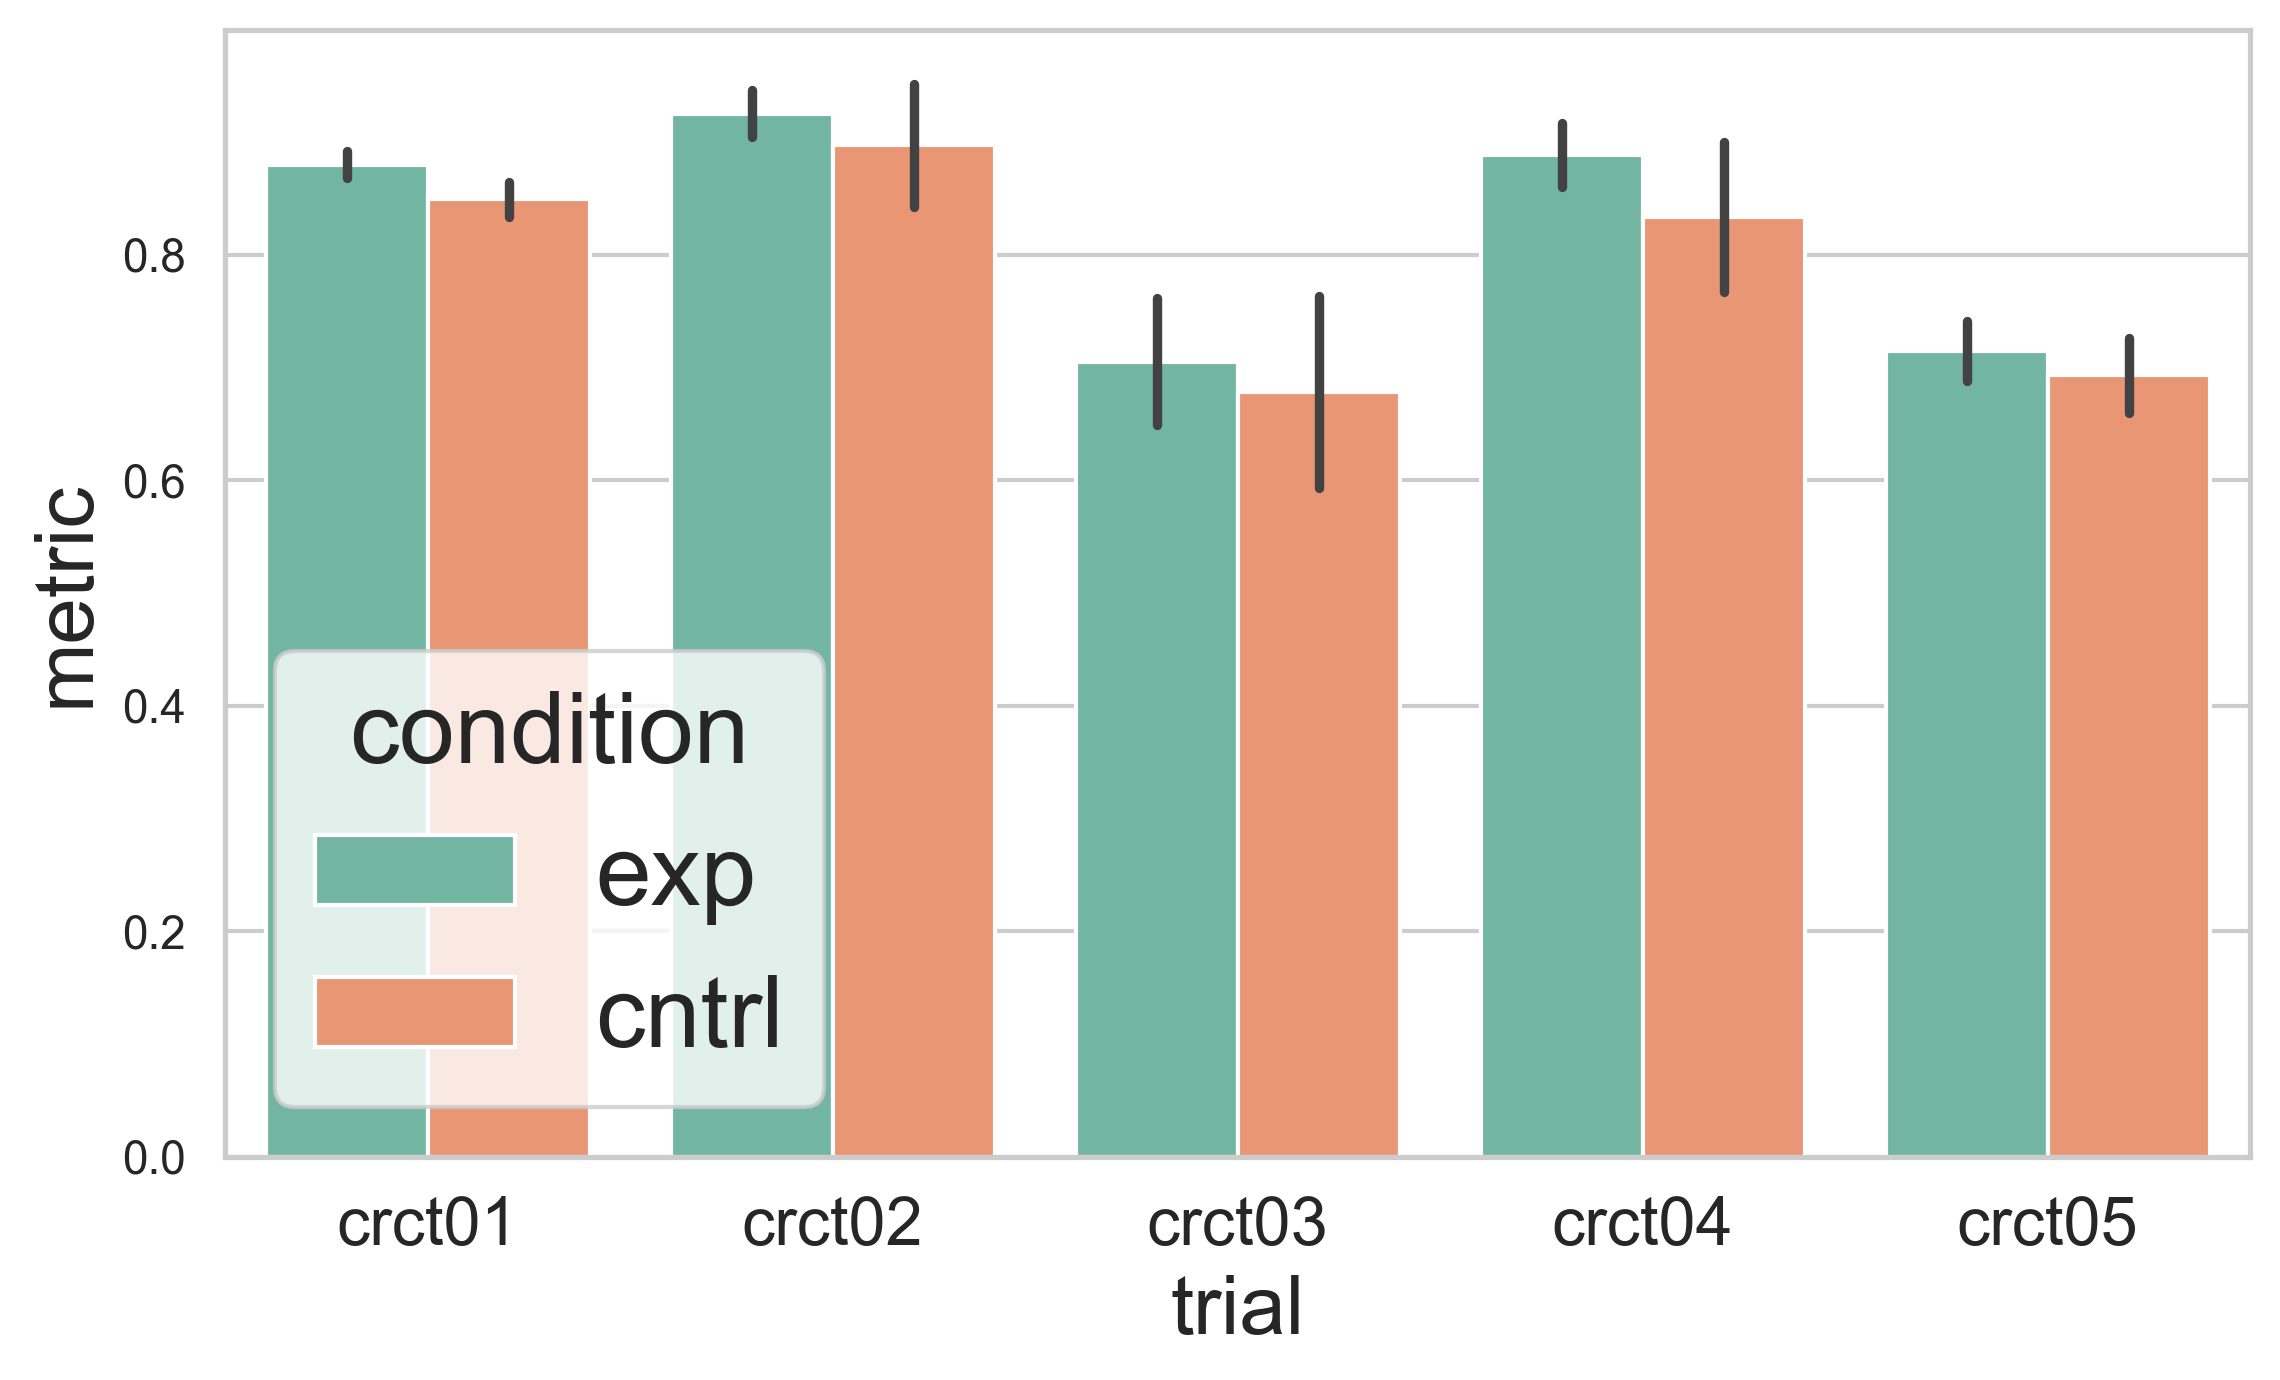

In [71]:
pg.print_table(t_h1)
fig_h1.show() if plotmode == 'plotly' else display(fig_h1.figure)

## **_Hypothesis 2_**
**_Humans who saw explanations perform better than humans who did not on transfer domains (waterflow and lists)._**

In [72]:
flow_trials = [col for col in trial_cols if 'flow' in col]
list_trials = [col for col in trial_cols if 'list' in col]

df_h2_flow = df.reset_index().melt(id_vars = ['condition', 'index'], value_vars = flow_trials, var_name = 'trial', value_name = 'metric')
df_h2_list = df.reset_index().melt(id_vars = ['condition', 'index'], value_vars = list_trials, var_name = 'trial', value_name = 'metric')

df_h2_flow['condition'] = df_h2_flow['condition'].cat.rename_categories(['exp', 'cntrl']) if 'simulate' not in modifications else df_h2_flow['condition'].cat.rename_categories(['exp', 'cntrl', 'rnd'])
df_h2_list['condition'] = df_h2_list['condition'].cat.rename_categories(['exp', 'cntrl']) if 'simulate' not in modifications else df_h2_list['condition'].cat.rename_categories(['exp', 'cntrl', 'rnd'])

if 'exclude_missing' in modifications:
    df_h2_flow = df_h2_flow[df_h2_flow['metric'] != -1]

if 'exclude_missing' in modifications:
    df_h2_list = df_h2_list[df_h2_list['metric'] != -1]

In [73]:
if plotmode == 'plotly':
    fig_h2_flow = px.bar(
        (_df := df_h2_flow.groupby(['condition', 'trial'], observed = True)['metric'].agg(['mean', 'sem'])),
        x = _df.index.get_level_values(1),
        y = 'mean',
        error_y = 'sem',
        color = _df.index.get_level_values(0),
        width = 800,
        title = '<b>Waterflow Domain</b>',
        barmode = 'group'
    )
elif plotmode == 'seaborn':
    plt.figure()
    with warnings.catch_warnings():
        warnings.filterwarnings(action = 'ignore', category = UserWarning)
        fig_h2_flow = sns.barplot(
            data = df_h2_flow,
            x = 'trial',
            y = 'metric',
            hue = 'condition',
            errorbar = 'se',
            palette = sns.color_palette('Set2')
        )
    plt.legend(title = 'condition', fontsize = 'large', title_fontsize = 'large')
    plt.savefig('./plots/fig_q4_flow.pgf') if 'save' in modifications else None
    plt.close()

t_h2_flow = pg.mwu(
    x = df_h2_flow[df_h2_flow['condition'] == 'exp']['metric'],
    y = df_h2_flow[df_h2_flow['condition'] == 'cntrl']['metric'],
    alternative = 'greater'
)

norm = pg.normality(df_h2_flow, 'metric', group = 'condition')
var = pg.homoscedasticity(df_h2_flow, 'metric', group = 'condition')
pg.print_table(norm)
pg.print_table(var)

if plotmode == 'plotly':
    fig_h2_list = px.bar(
        (_df := df_h2_list.groupby(['condition', 'trial'], observed = True)['metric'].agg(['mean', 'sem'])),
        x = _df.index.get_level_values(1),
        y = 'mean',
        error_y = 'sem',
        color = _df.index.get_level_values(0),
        width = 800,
        title = '<b>List Domain</b>',
        barmode = 'group'
    )
elif plotmode == 'seaborn':
    plt.figure()
    with warnings.catch_warnings():
        warnings.filterwarnings(action = 'ignore', category = UserWarning)
        fig_h2_list = sns.barplot(
            data = df_h2_list,
            x = 'trial',
            y = 'metric',
            hue = 'condition',
            errorbar = 'se',
            palette = sns.color_palette('Set2')
        )
    plt.legend(title = 'condition', fontsize = 'large', title_fontsize = 'large')
    plt.savefig('./plots/fig_q4_list.pgf') if 'save' in modifications else None
    plt.close()

t_h2_list = pg.mwu(
    x = df_h2_list[df_h2_list['condition'] == 'exp']['metric'],
    y = df_h2_list[df_h2_list['condition'] == 'cntrl']['metric'],
    alternative = 'greater'
)

norm = pg.normality(df_h2_list, 'metric', group = 'condition')
var = pg.homoscedasticity(df_h2_list, 'metric', group = 'condition')
pg.print_table(norm)
pg.print_table(var)

    W    pval  normal
-----  ------  --------
0.610   0.000  False
0.612   0.000  False

    W    pval  equal_var
-----  ------  -----------
0.747   0.388  True

    W    pval  normal
-----  ------  --------
0.627   0.000  False
0.579   0.000  False

    W    pval  equal_var
-----  ------  -----------
0.884   0.348  True



    U-val  alternative      p-val    RBC    CLES
---------  -------------  -------  -----  ------
16847.500  greater          0.470  0.004   0.502



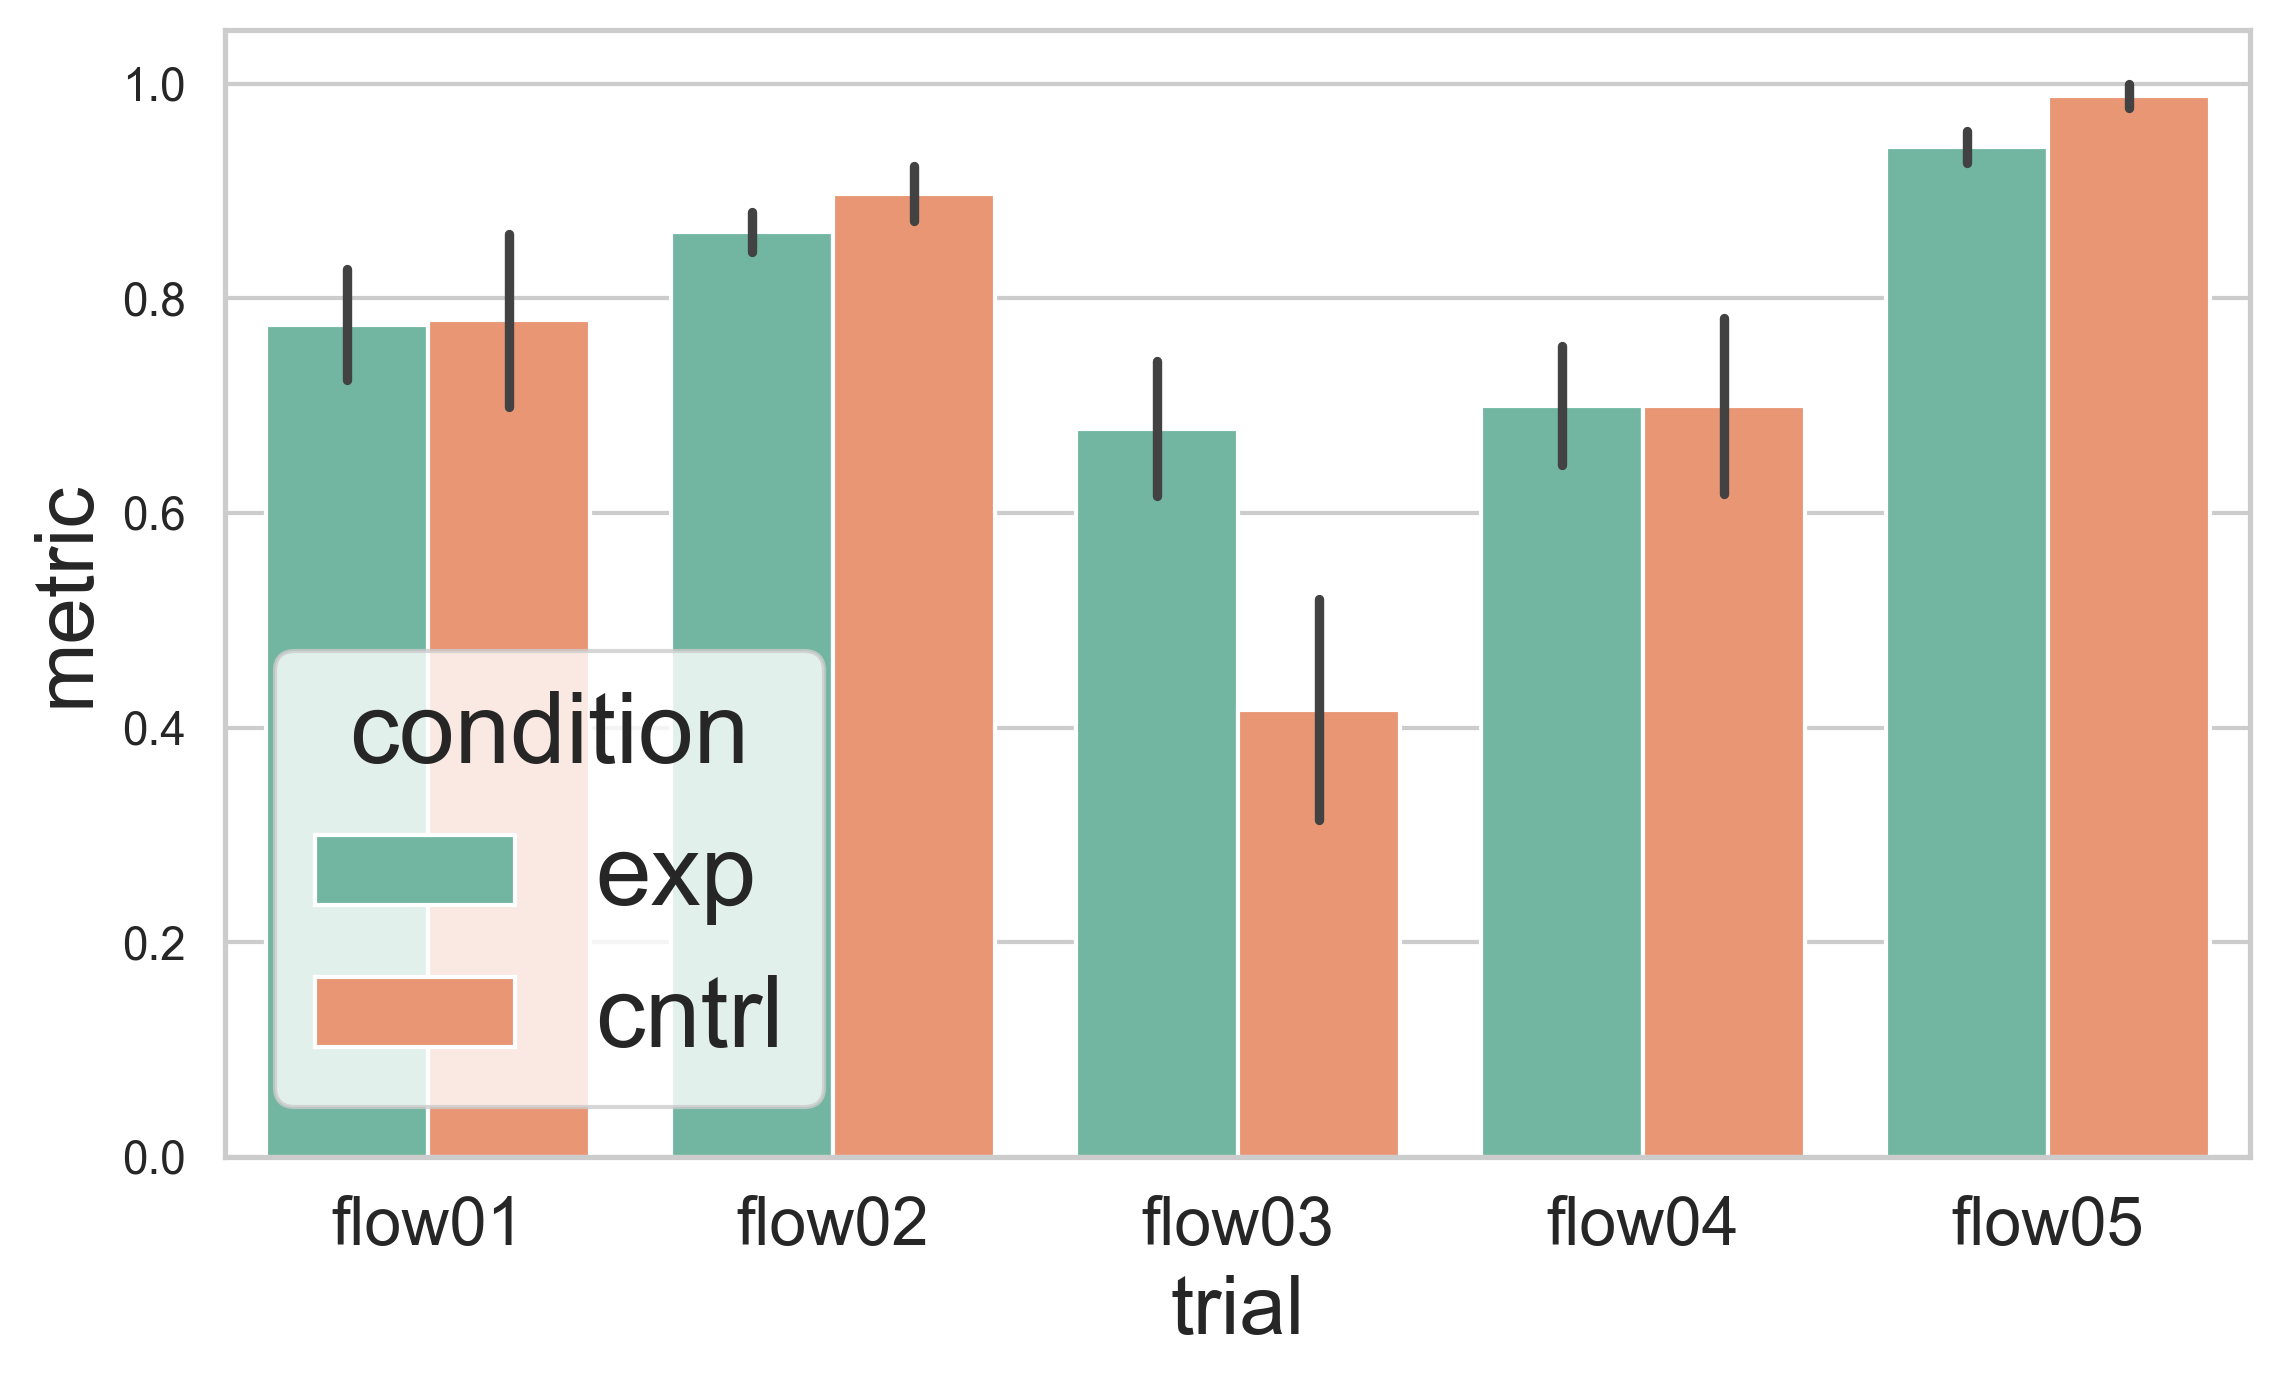

In [74]:
pg.print_table(t_h2_flow)
fig_h2_flow.show() if plotmode == 'plotly' else display(fig_h2_flow.figure)

    U-val  alternative      p-val    RBC    CLES
---------  -------------  -------  -----  ------
16621.000  greater          0.152  0.058   0.529



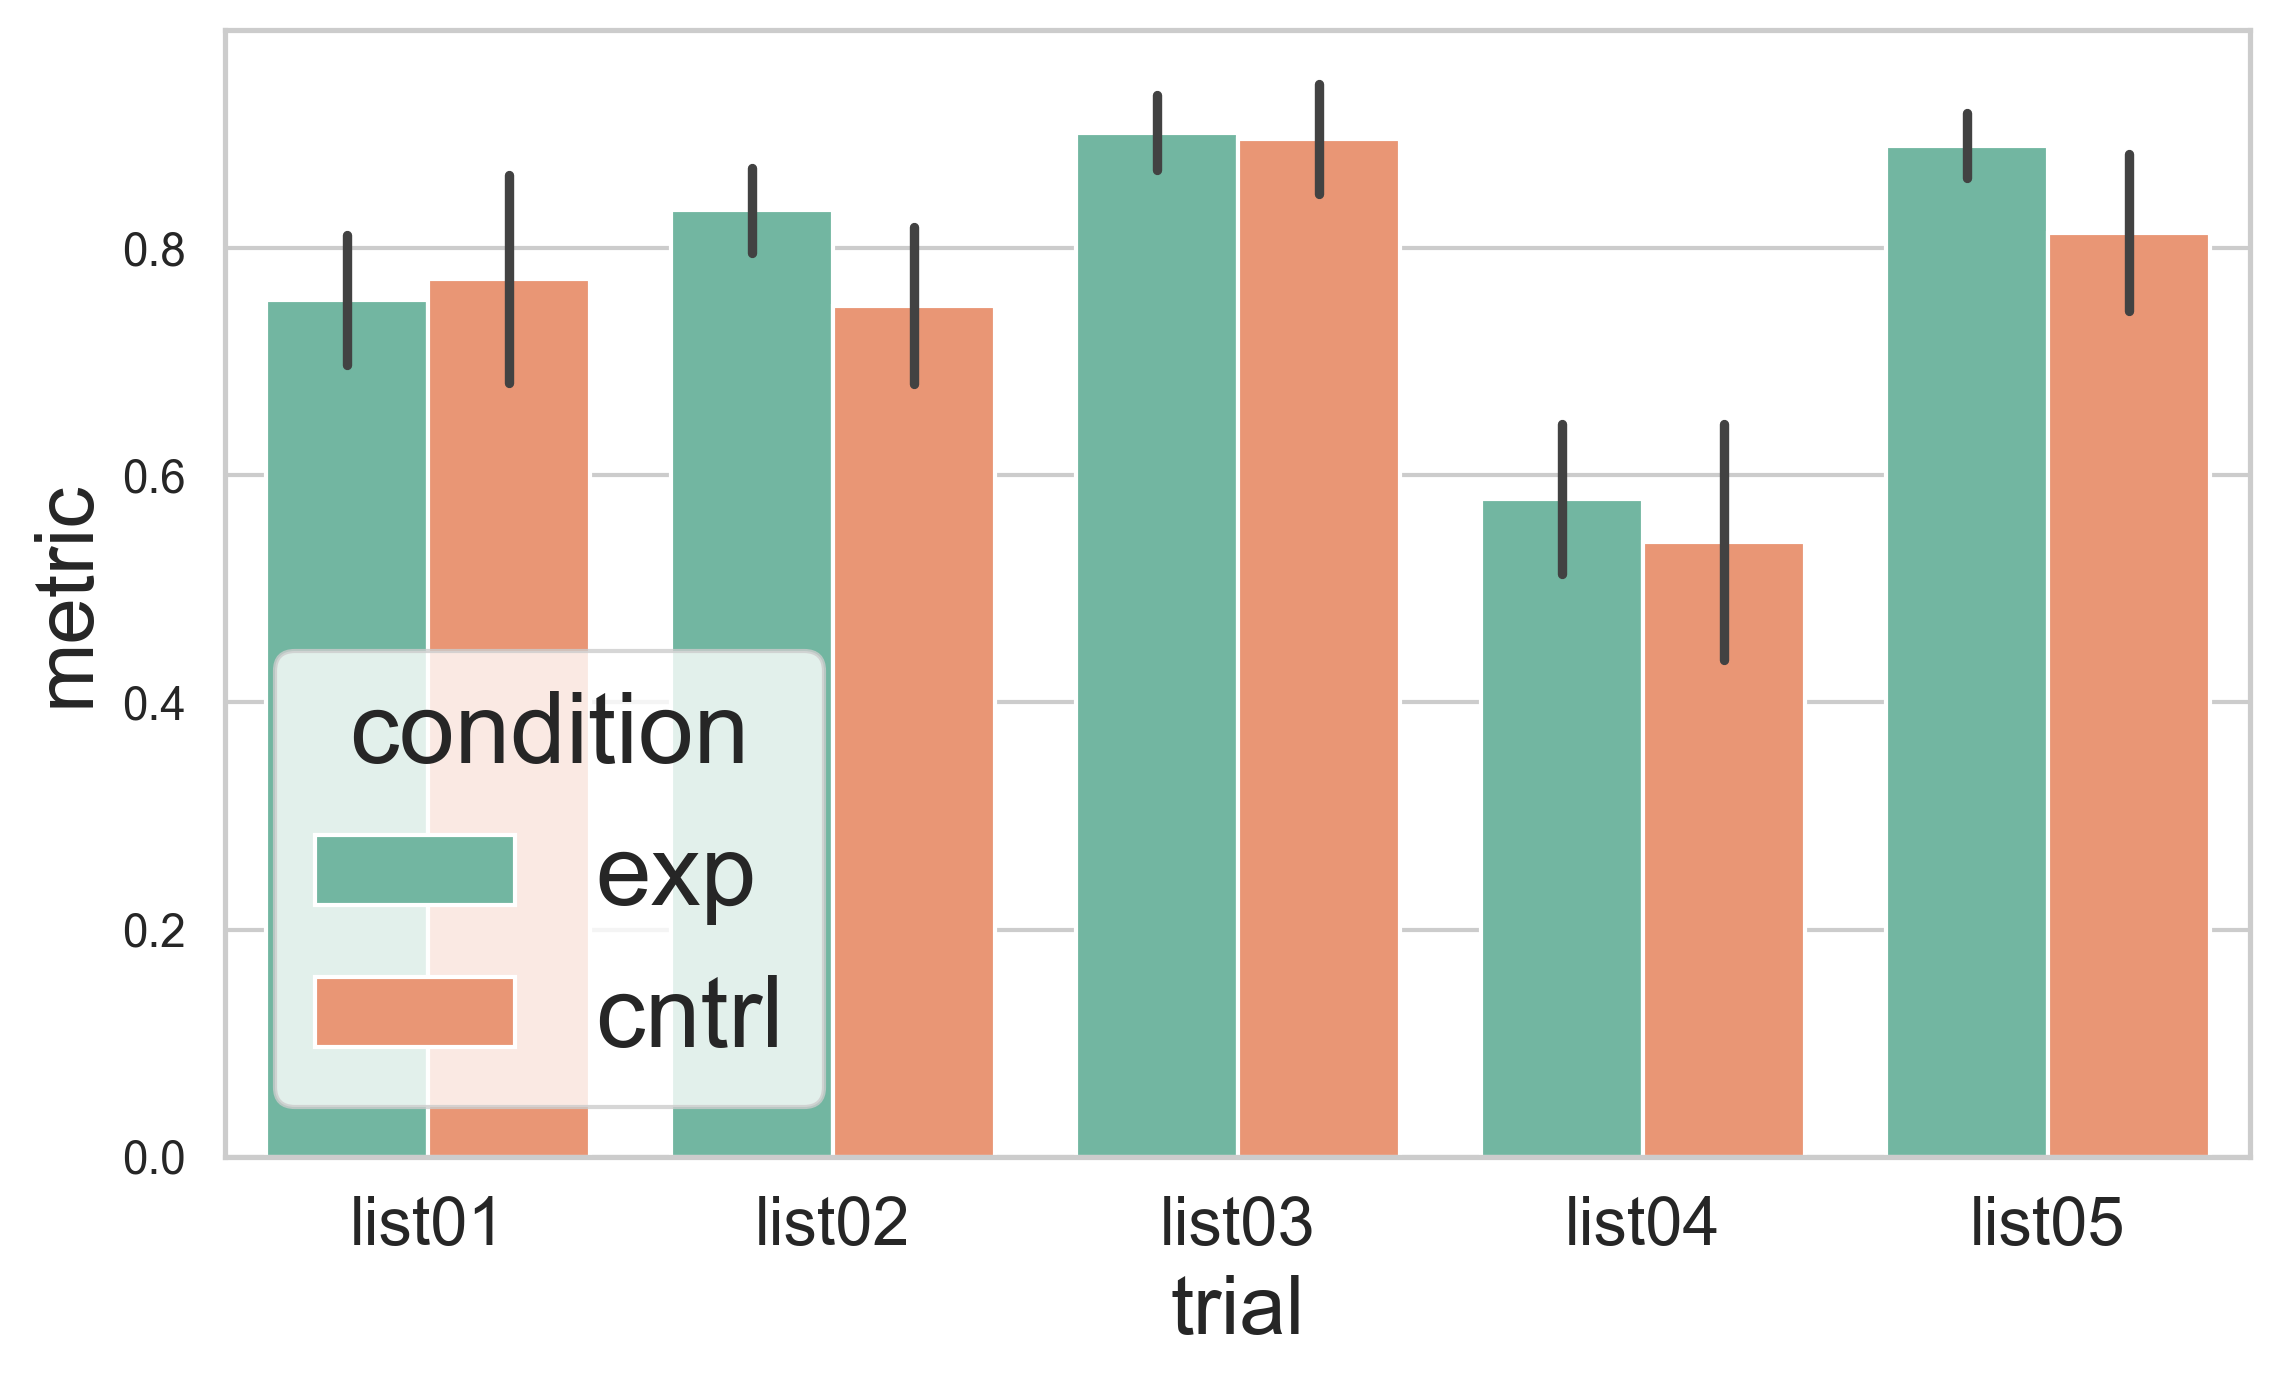

In [75]:
pg.print_table(t_h2_list)
fig_h2_list.show() if plotmode == 'plotly' else display(fig_h2_list.figure)

## **_Check Random_**

In [76]:
if 'simulate' in modifications:
    t_h1_random = pg.mwu(
        x = df_h1[df_h1['condition'] == 'rnd']['metric'],
        y = df_h1[df_h1['condition'] != 'rnd']['metric'],
        alternative = 'two-sided'
    )
    t_h2_flow_random = pg.mwu(
        x = df_h2_flow[df_h2_flow['condition'] == 'rnd']['metric'],
        y = df_h2_flow[df_h2_flow['condition'] != 'rnd']['metric'],
        alternative = 'two-sided'
    )
    t_h2_list_random = pg.mwu(
        x = df_h2_list[df_h2_list['condition'] == 'rnd']['metric'],
        y = df_h2_list[df_h2_list['condition'] != 'rnd']['metric'],
        alternative = 'two-sided'
    )
    # df_h1['domain'] = 'crct'
    # df_h2_flow['domain'] = 'flow'
    # df_h2_list['domain'] = 'list'
    _df = pd.concat([df_h1, df_h2_flow, df_h2_list], axis = 0)

    all_doms = pg.mwu(
        x = _df[_df['condition'] == 'rnd']['metric'],
        y = _df[_df['condition'] != 'rnd']['metric'],
        alternative = 'two-sided'
    )

    with warnings.catch_warnings():
        warnings.filterwarnings(action = 'ignore', category = FutureWarning)
        pg.print_table(pd.concat([t_h1_random, t_h2_flow_random, t_h2_list_random]))
        pg.print_table(all_doms)

## **_Summary_**

In [77]:
df_figure = df.reset_index().melt(id_vars = ['condition', 'index'], value_vars = trial_cols, var_name = 'item', value_name = 'metric')
df_figure['condition'] = df_figure['condition'].cat.rename_categories((['H2', 'H1'] if 'simulate' not in modifications else ['exp', 'cntrl', 'rnd']))
# df_figure['domain'] = [item[:4] for item in df_figure['item']]
df_figure['domain'] = ['Electrical Circuits' if 'crct' in item else 'Waterflow' if 'flow' in item else 'List Binary Search' for item in df_figure['item']]

if 'exclude_missing' in modifications:
    df_figure = df_figure[df_figure['metric'] != -1]

if plotmode == 'plotly':
    fig_summary = px.bar(
        (_df := df_figure.groupby(['condition', 'domain'], observed = True)['metric'].agg(['mean', 'sem'])),
        x = _df.index.get_level_values(1),
        y = 'mean',
        error_y = 'sem',
        color = _df.index.get_level_values(0),
        width = 800,
        title = '<b>Performance per Domain and Condition</b>',
        barmode = 'group'
    )
elif plotmode == 'seaborn':
    plt.figure()
    with warnings.catch_warnings():
        warnings.filterwarnings(action = 'ignore', category = UserWarning)
        fig_summary = sns.barplot(
            data = df_figure,
            x = 'domain',
            y = 'metric',
            hue = 'condition',
            errorbar = 'se',
            palette = sns.color_palette('Set2')
        )
    plt.legend(title = 'condition', fontsize = 'large', title_fontsize = 'large')
    plt.savefig('./plots/fig_sum.pgf') if 'save' in modifications else None
    plt.close()

domain        U-val  alternative      p-val    RBC    CLES
--------  ---------  -------------  -------  -----  ------
crct      18514.500  greater          0.130  0.067   0.533
flow      16847.500  greater          0.470  0.004   0.502
list      16621.000  greater          0.152  0.058   0.529



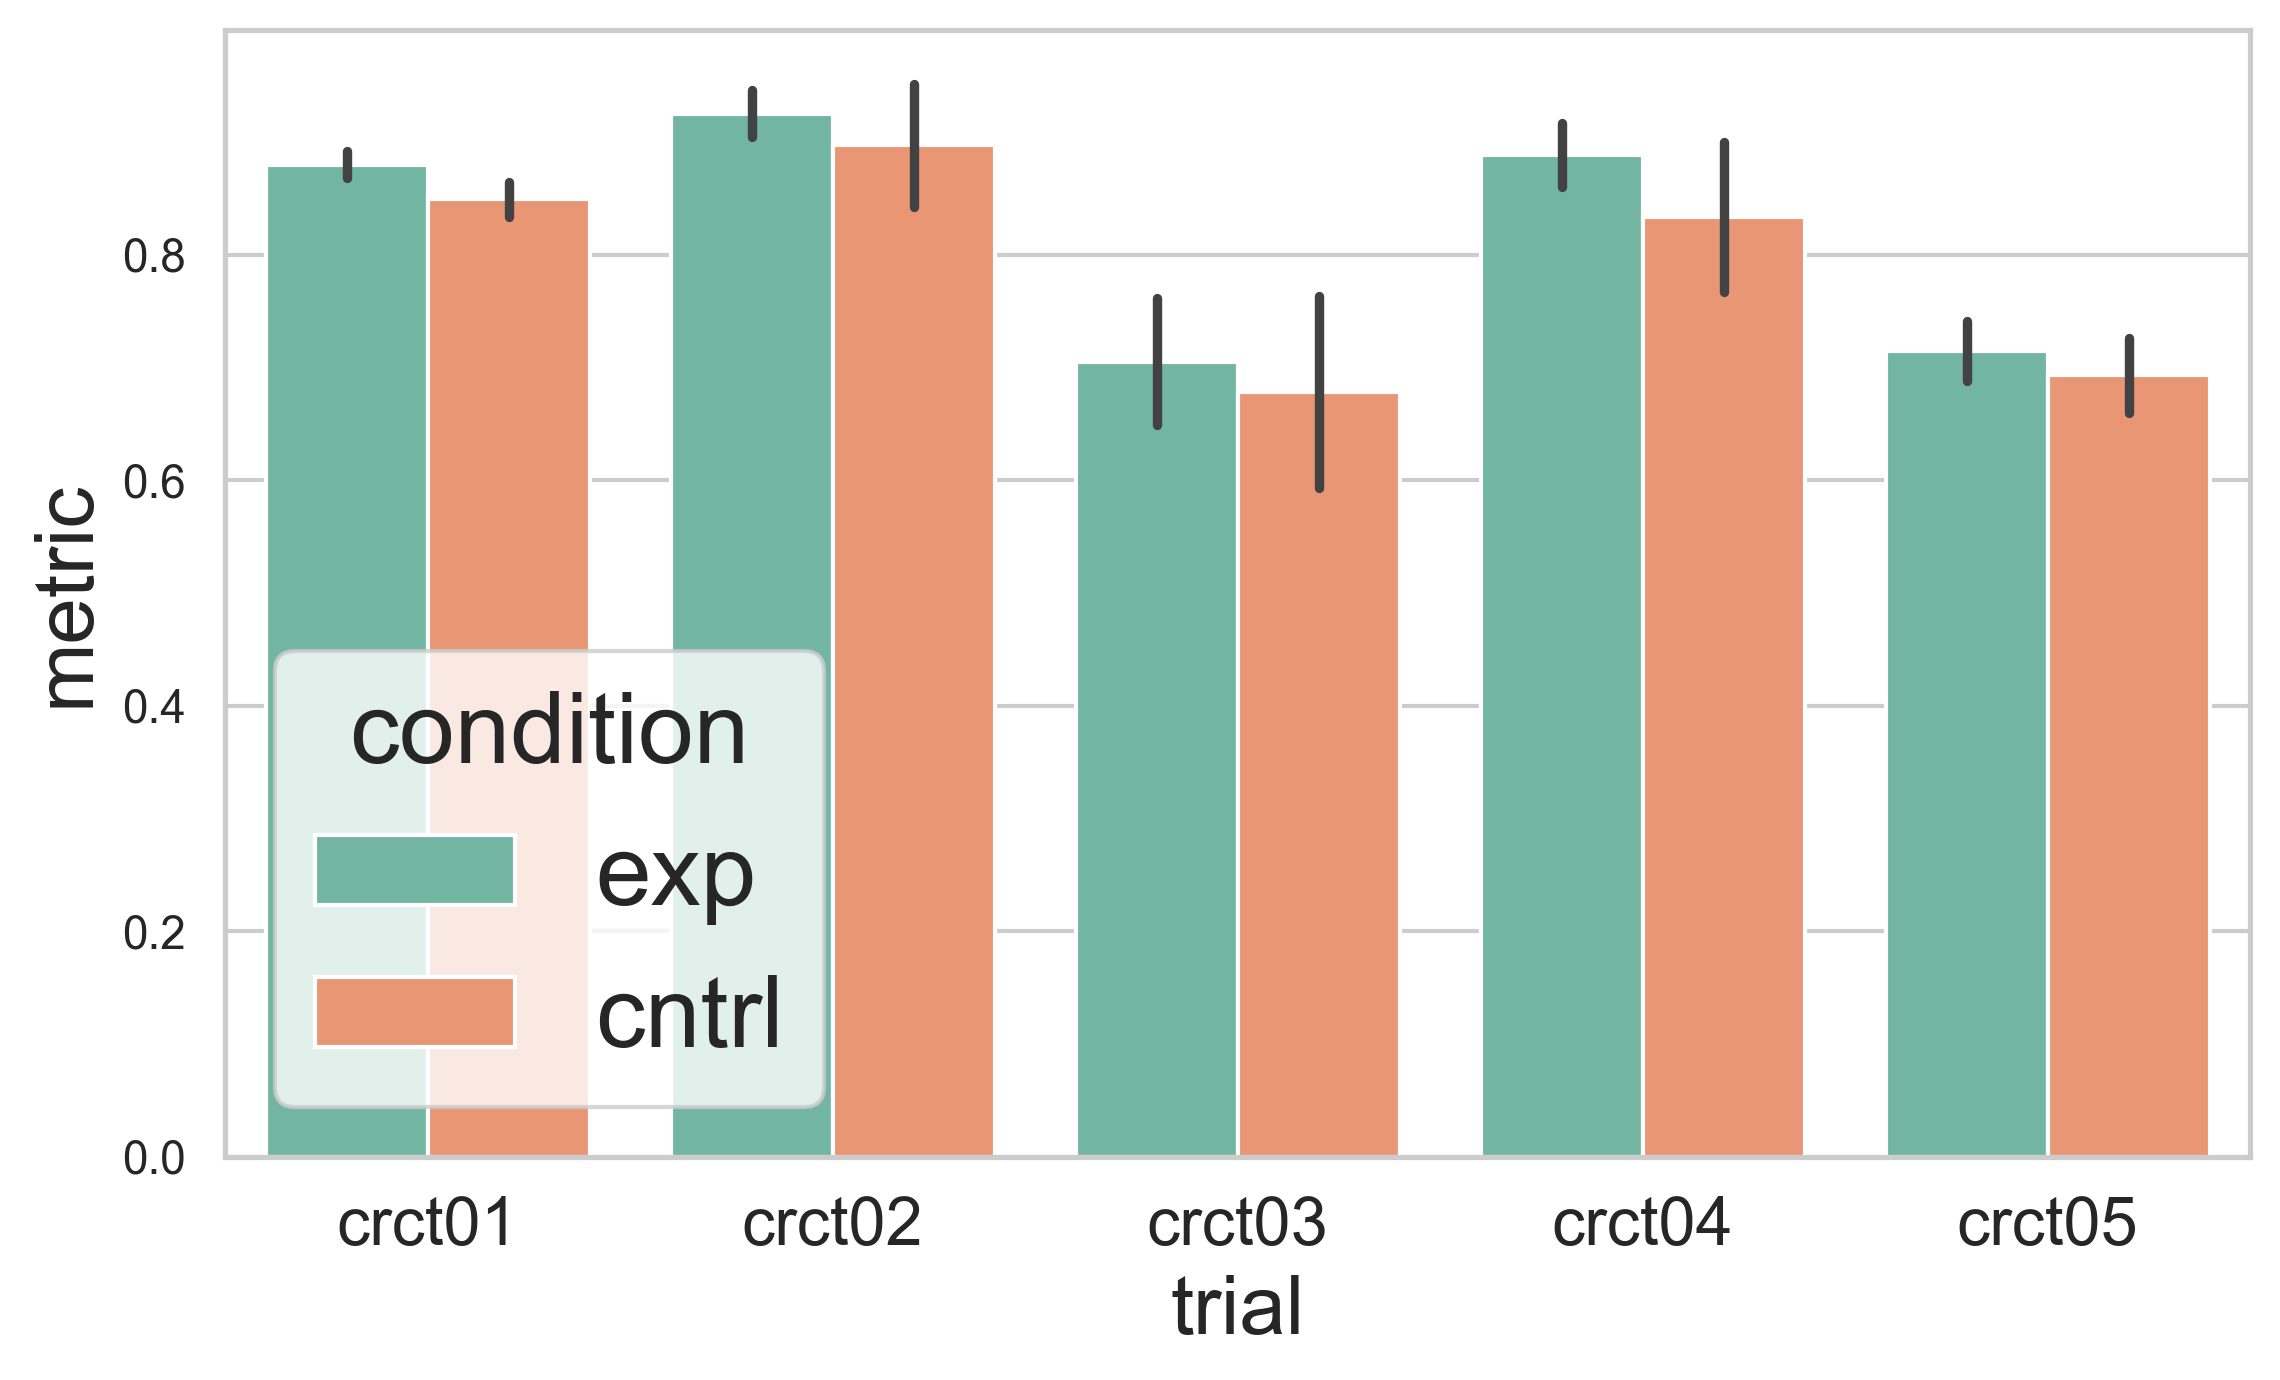

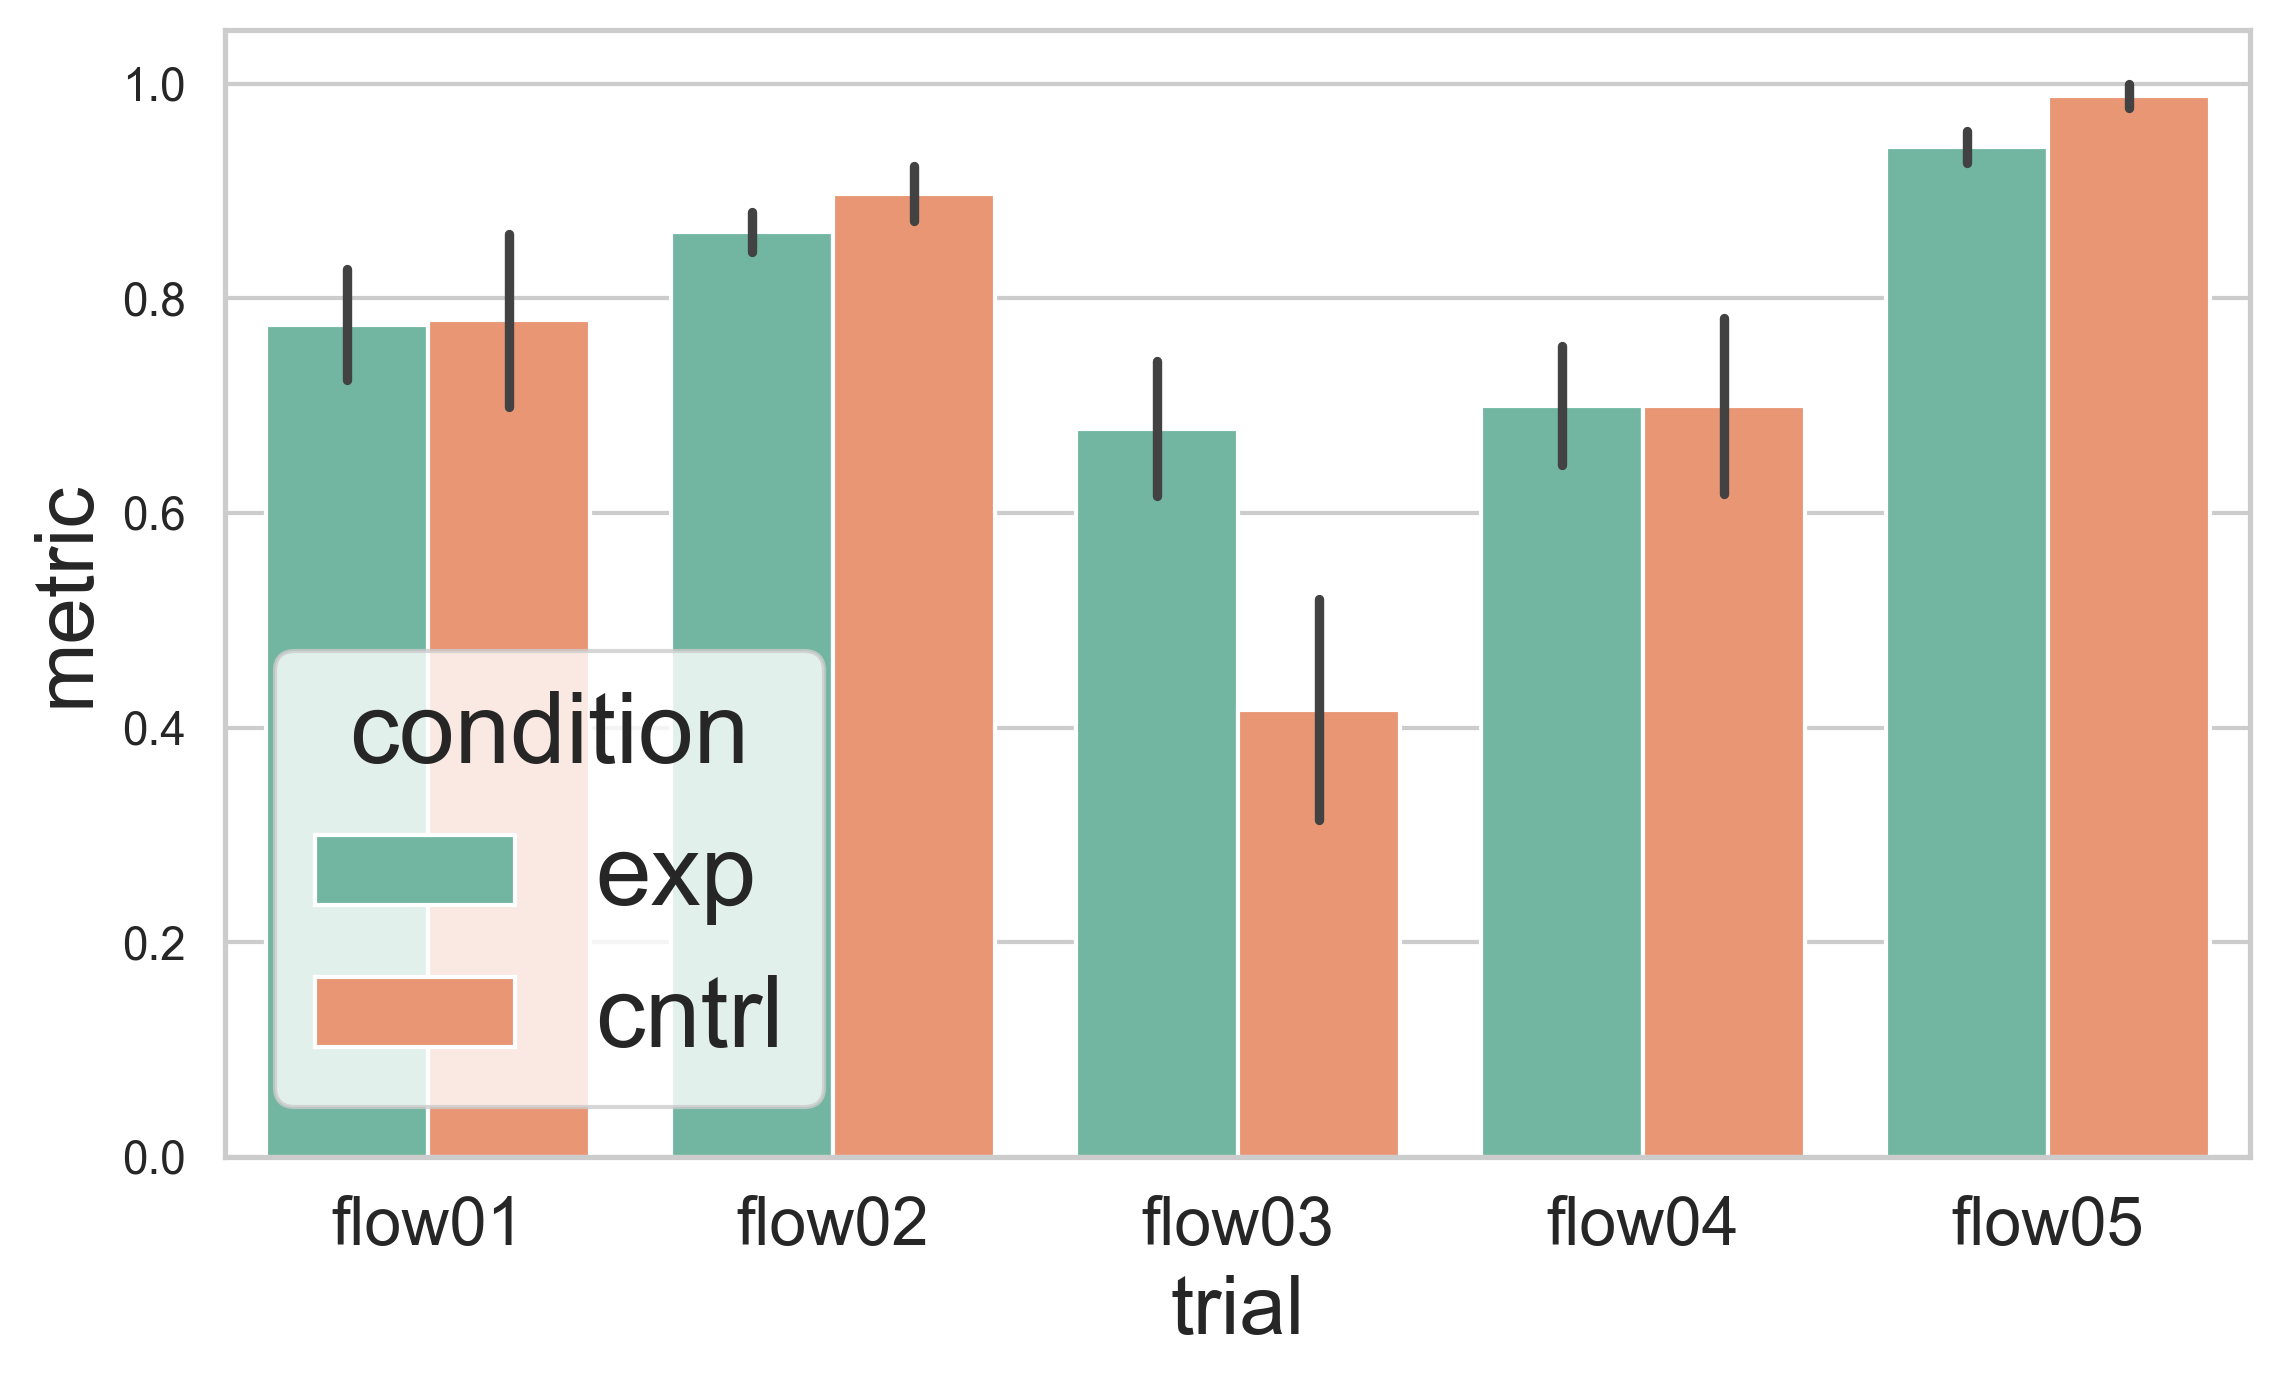

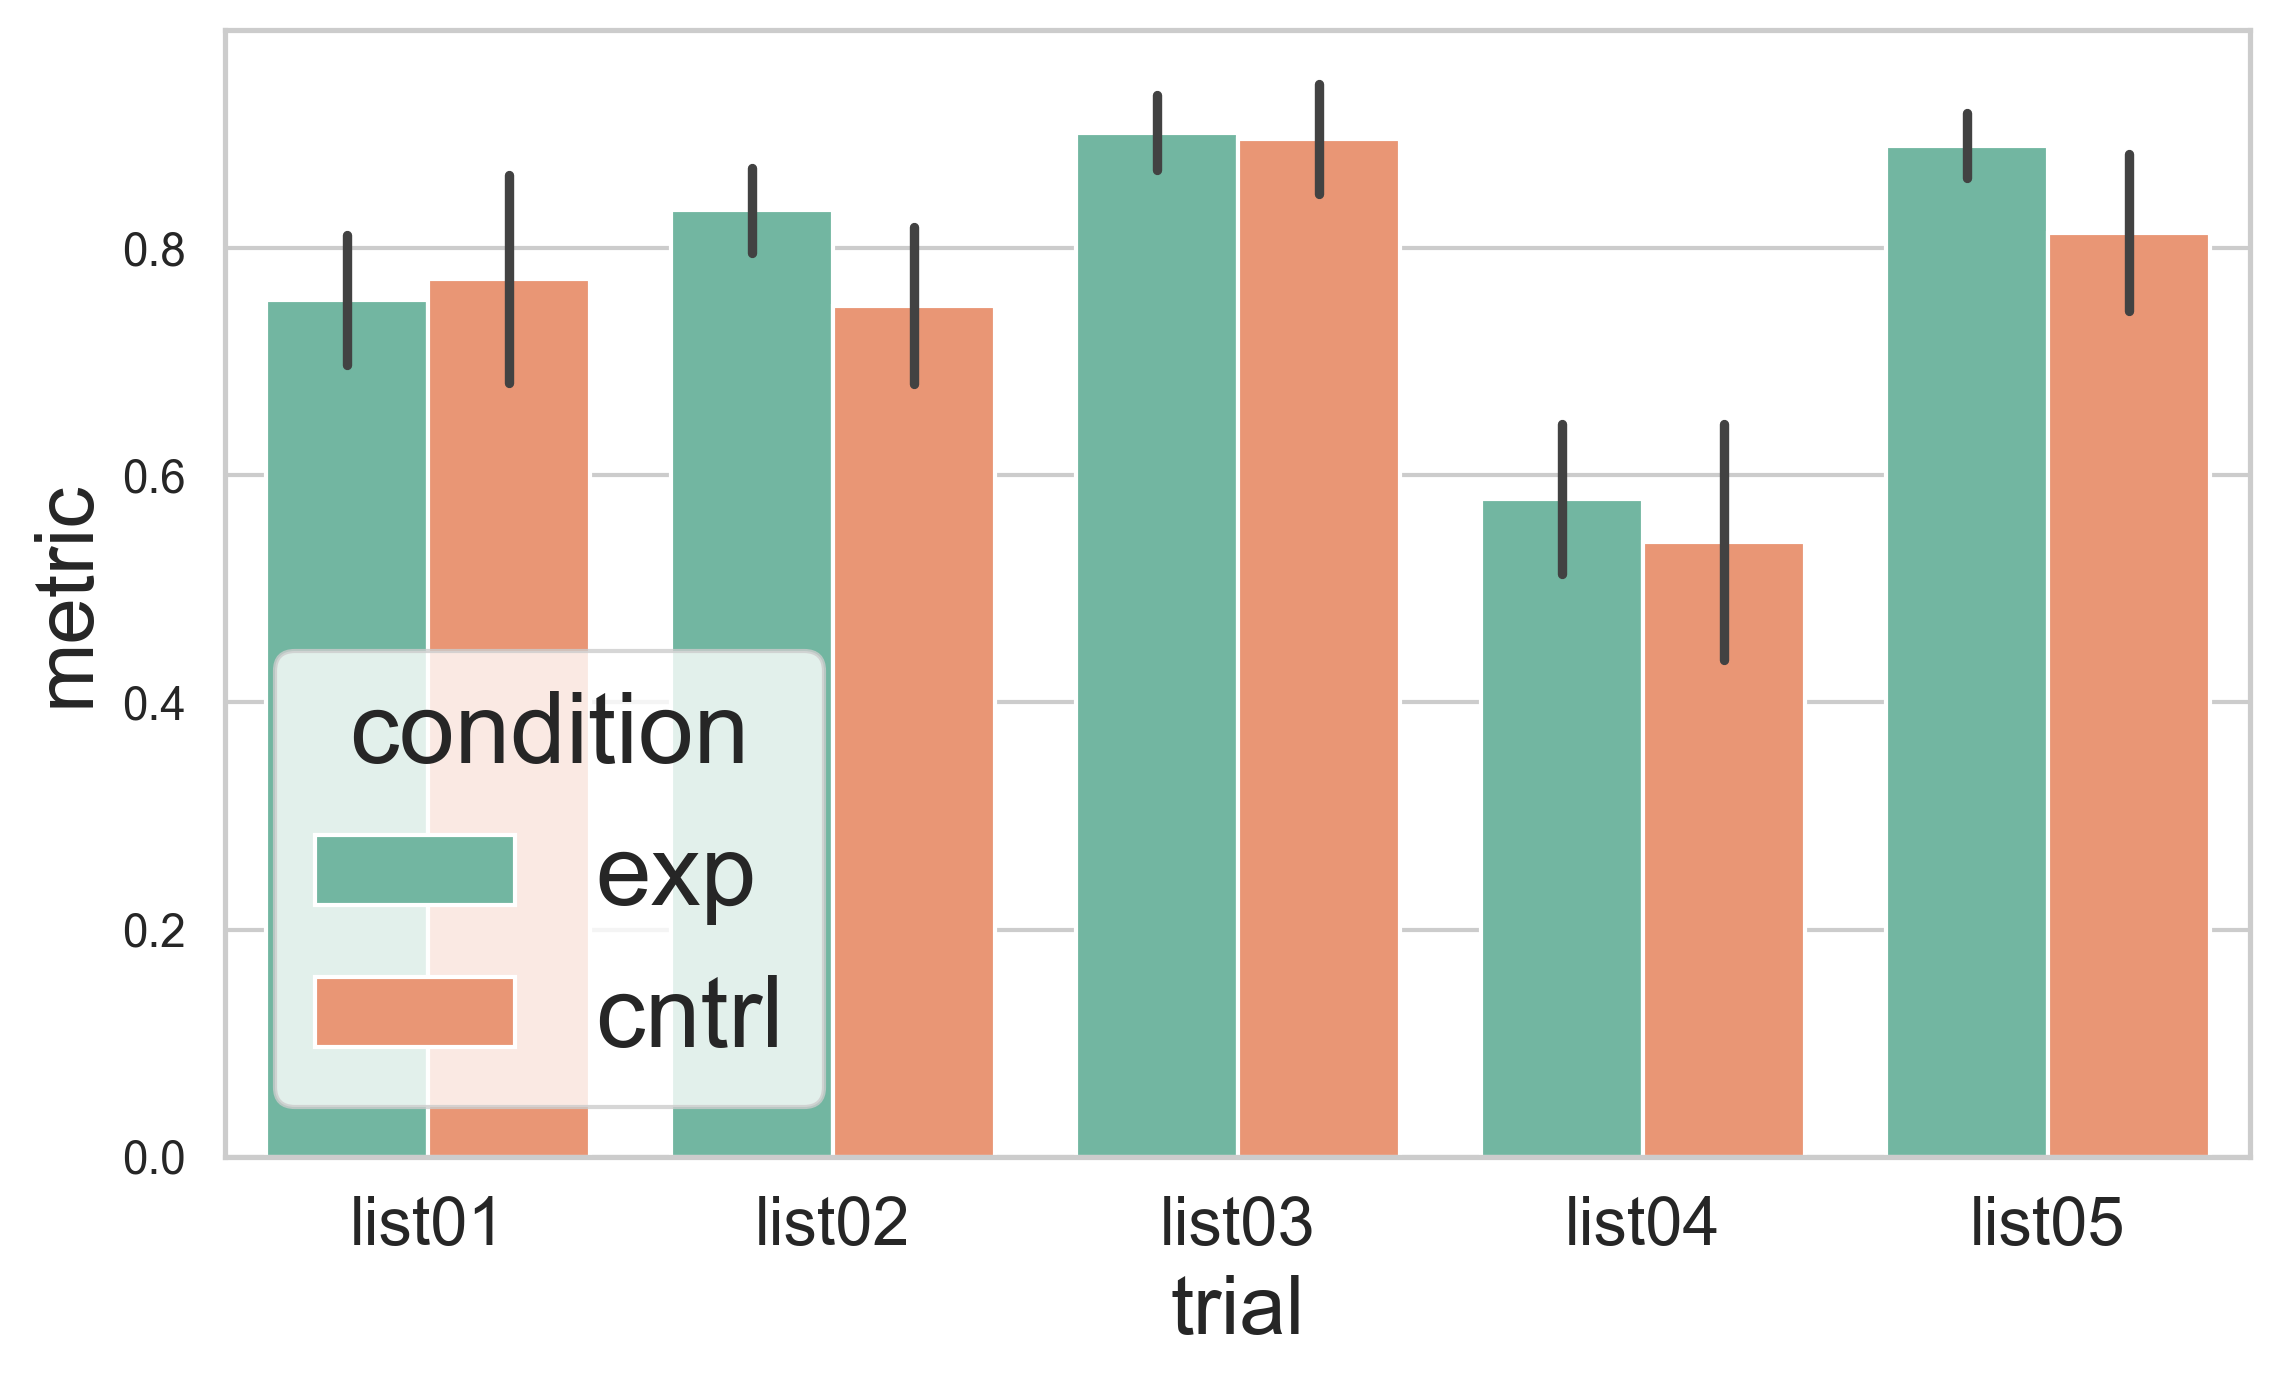

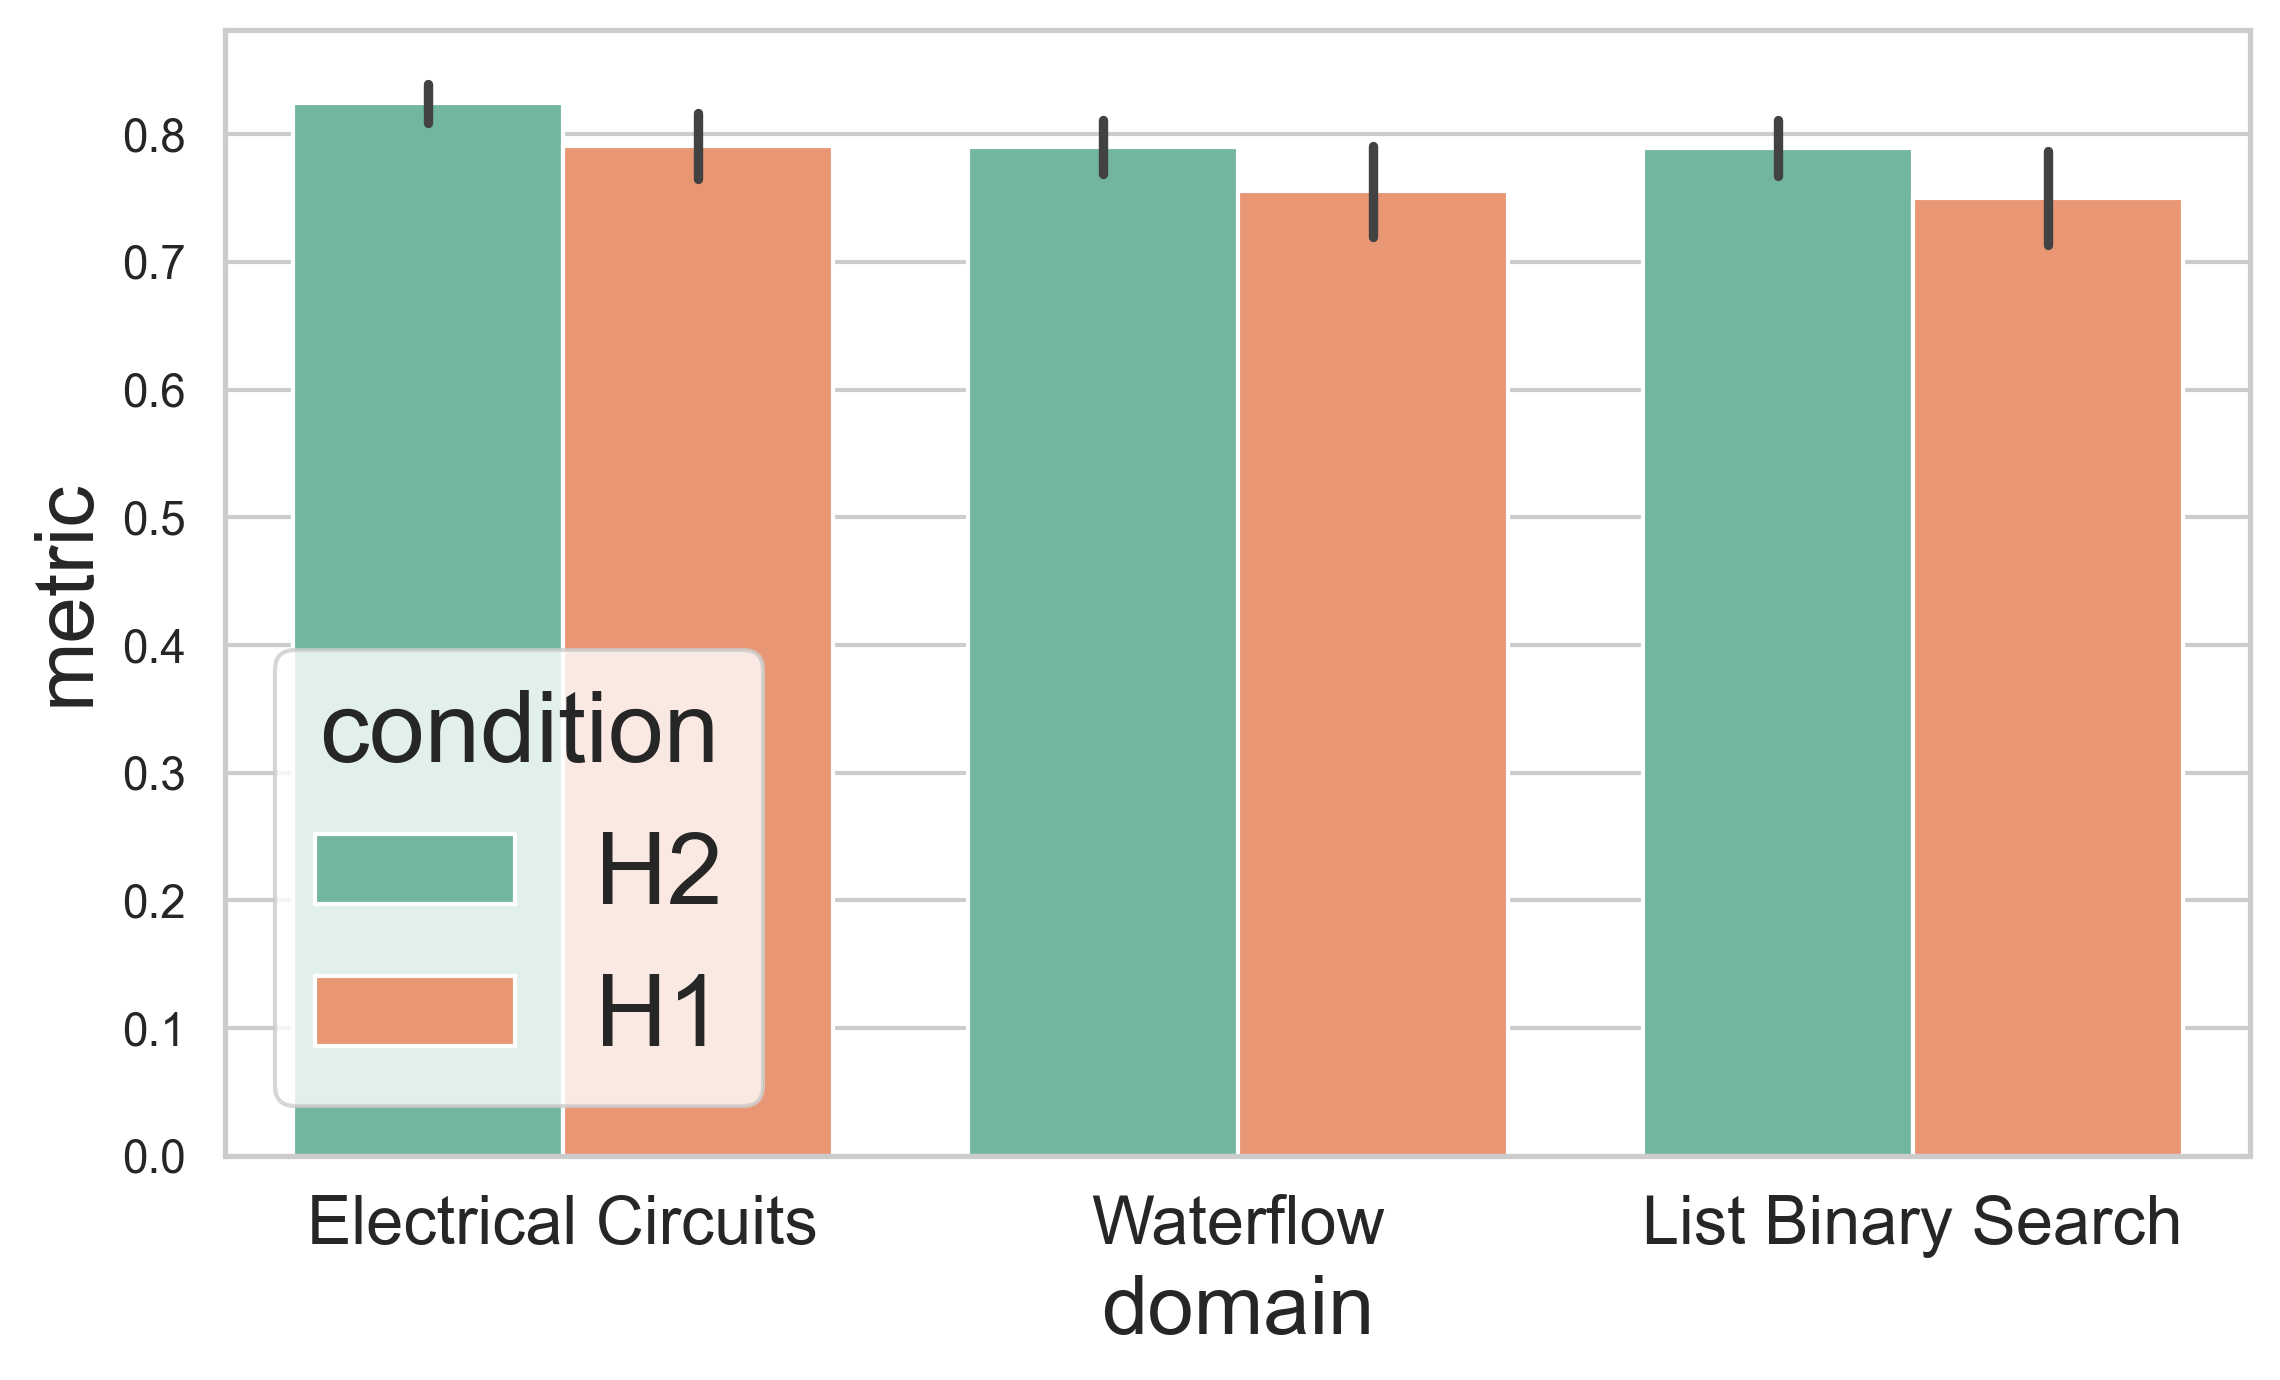

In [78]:
t_df = pd.concat([t_h1, t_h2_flow, t_h2_list])
t_df['domain'] = ['crct', 'flow', 'list']
t_df = pd.concat([
    pd.DataFrame(t_df['domain']),
    t_df.drop('domain', axis = 1)
], axis = 1)
pg.print_table(t_df)

fig_h1.show() if plotmode == 'plotly' else display(fig_h1.figure)
fig_h2_flow.show() if plotmode == 'plotly' else display(fig_h2_flow.figure)
fig_h2_list.show() if plotmode == 'plotly' else display(fig_h2_list.figure)
fig_summary.show() if plotmode == 'plotly' else display(fig_summary.figure)